# Impact of $A$ on dipole + $m_5$ map study

The goal of this notebook is to study the impact of A on the injected dipole measurement when the $m_5$ is added.

In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
%matplotlib inline
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table
import fitsio

from simulMap import *
from fitMap import *
from utile_fitsFile import *
from lumMag_sampling import *
from mappers import CountMapper, DepthMapper
from spectra import Spectrum

In [2]:
#sources:
NSource_px_th = int(1e6)
#print("Total number of sources in the entire sky : {}".format(NSource_px_th*npix))
print("Theorical number of sources in one pixel : {}".format(NSource_px_th))

Theorical number of sources in one pixel : 1000000


## Data without dipole

In [3]:
DIR_NoDip = "Fit_m5/m5_NoDipole/m5_NoDipole_"
suffix_poiss = "_poissVar"
suffix = "Footprint_study"
fileNoDip = DIR_NoDip + suffix + suffix_poiss +".fits"

data = fitsio.FITS(fileNoDip)
data


  file: Fit_m5/m5_NoDipole/m5_NoDipole_Footprint_study_poissVar.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      MAPS_BAND_i
  2      BINARY_TBL      BAND_i
  3      BINARY_TBL      MAPS_BAND_u
  4      BINARY_TBL      BAND_u
  5      BINARY_TBL      MAPS_BAND_z
  6      BINARY_TBL      BAND_z

In [4]:
band = "u"
HDU_target=f'BAND_{band}'

dfMinuit_NoDip = Table(data[HDU_target].read()).to_pandas()
m5Stats = dfMinuit_NoDip.describe()
m5Stats['A']

/home/victoria/.local/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/victoria/.local/lib/python3.10/site-packages/numpy/lib/function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


count    1.000000e+02
mean     3.428751e-05
std      1.746033e-05
min      2.584264e-13
25%      2.125124e-05
50%      3.327376e-05
75%      4.668217e-05
max      8.363107e-05
Name: A, dtype: float64

## Study without clustering

In [5]:
DIR = "Fit_m5/m5_Dipole/m5_Dipole_"
sufix = "Param_study_NoCluster_poissVar"
outputfile = DIR + sufix +".fits"

data2 = fitsio.FITS(outputfile)
data2


  file: Fit_m5/m5_Dipole/m5_Dipole_Param_study_NoCluster_poissVar.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      A_STUDY_MAPS_u
  2      BINARY_TBL      A_STUDY
  3      BINARY_TBL      A_STUDY_MAPS_i
  4      BINARY_TBL      A_STUDY_MAPS_z

In [6]:
dfMinuit_data2 = Table(data2['A_STUDY'].read())
dfMinuit_data2['A+Am5'] = dfMinuit_data2['A'] + m5Stats['A']['mean']
dfMinuit_data2['A+Am5_err'] = np.sqrt(dfMinuit_data2['A_err']**2 + m5Stats['A']['std']**2)
mask = dfMinuit_data2["BAND"] == band
dfMinuit_filtered = dfMinuit_data2[mask]
dfMinuit_filtered

Map_ID,N*,N*_init,N*_err,N*_fixed,N*_limit_0,N*_limit_1,A,A_init,A_err,A_fixed,A_limit_0,A_limit_1,ra,ra_init,ra_err,ra_fixed,ra_limit_0,ra_limit_1,dec,dec_init,dec_err,dec_fixed,dec_limit_0,dec_limit_1,valid,Nth_ID,Ratio_ID,BAND,N*_true,A_true,ra_true,dec_true,A+Am5,A+Am5_err
str26,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,bool,str26,str26,str1,int64,float64,int64,int64,float64,float64
01KT6G216466YPM2RQW6BXKAWM,1000004.1162152069,1000000.0,8.844351512030698,False,0.0,inf,0.000981524296842746,1.0,1.0125378750887684e-05,False,0.0,1.0,169.67483190350384,100.0,0.5718505489377605,False,0.0,360.0,-5.176890317261793,0.0,0.9593227514173481,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.001,168,-7,0.0010158118110375819,2.0183812039455382e-05
01KT6G2671AQYTZ40HNP0CZGA2,999991.4115696838,1000000.0,8.846327910432592,False,0.0,inf,0.0010626607484862142,1.0,1.0226407726678165e-05,False,0.0,1.0,168.90100333161357,100.0,0.529820981041496,False,0.0,360.0,-6.6923413550028625,0.0,0.8828808659531502,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.0010985411419875584,168,-7,0.00109694826268105,2.023468281410408e-05
01KT6G29ZFETZYW1D9WSHMFGYM,999986.8354358278,1000000.0,8.844099869253114,False,0.0,inf,0.001193378277083721,1.0,1.0142071148242014e-05,False,0.0,1.0,168.6153818459557,100.0,0.470821223409132,False,0.0,360.0,-5.521506873045254,0.0,0.7884145185273743,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.0012067926406393288,168,-7,0.0012276657912785567,2.0192191083959642e-05
01KT6G2E6BKVE46X4FVDK63R94,1000010.927913757,1000000.0,8.843862590147182,False,0.0,inf,0.0012985273556666746,1.0,1.0129363268645956e-05,False,0.0,1.0,168.9608985942164,100.0,0.4324607865838601,False,0.0,360.0,-5.298146786631958,0.0,0.7249070773735866,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.0013257113655901094,168,-7,0.0013328148698615104,2.0185811200527216e-05
01KT6G2JQMQKNFKZ1E5A9BXYRV,999999.8607869415,1000000.0,8.844244775362313,False,0.0,inf,0.0014250559885819866,1.0,1.016868376660829e-05,False,0.0,1.0,169.33881684622946,100.0,0.3943690439906362,False,0.0,360.0,-5.836579617490916,0.0,0.6596830836032361,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.0014563484775012444,168,-7,0.0014593435027768224,2.0205571091667246e-05
01KT6G2PW9M47GX06072CBKG28,1000017.5181802756,1000000.0,8.844245488289744,False,0.0,inf,0.0015649410581049473,1.0,1.0129498547547535e-05,False,0.0,1.0,167.9815787651411,100.0,0.3590553418817848,False,0.0,360.0,-5.385398834072111,0.0,0.6014669009851108,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.0015998587196060573,168,-7,0.0015992285722997831,2.0185879084644885e-05
01KT6G2V7F3J2AVQNC79Q8ARPQ,1000011.3631424813,1000000.0,8.844293380738236,False,0.0,inf,0.001734708854688005,1.0,1.0180897814194884e-05,False,0.0,1.0,168.12597756065367,100.0,0.32432170740268873,False,0.0,360.0,-6.122481554226553,0.0,0.5415977120529618,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.0017575106248547913,168,-7,0.0017689963688828408,2.0211720706021406e-05
01KT6G2ZV783V1JATB0A60ZNZW,999981.8567848867,1000000.0,8.844194217352197,False,0.0,inf,0.0019211874637634376,1.0,1.0260643796434349e-05,False,0.0,1.0,168.44284056311363,100.0,0.29344134020912804,False,0.0,360.0,-7.186759691463097,0.0,0.48760373375390076,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.0019306977288832496,168,-7,0.0019554749779582734,2.025200693048575e-05
01KT6G345H77EFRARKW0SVY43V,999993.2780008138,1000000.0,8.844057175214402,False,0.0,inf,0.0020962350657091062,1.0,1.0180000695065791e-05,False,0.0,1.0,167.65377950147516,100.0,0.26845889848647175,Fal

Saving m5_A_study_diffARaDec_NoCluster_band_u_PoissVar in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_NoCluster/Simul_Magnitude_ParamStudy_NoCluster_band_u/m5_A_study_diffARaDec_NoCluster_band_u_PoissVar.pdf


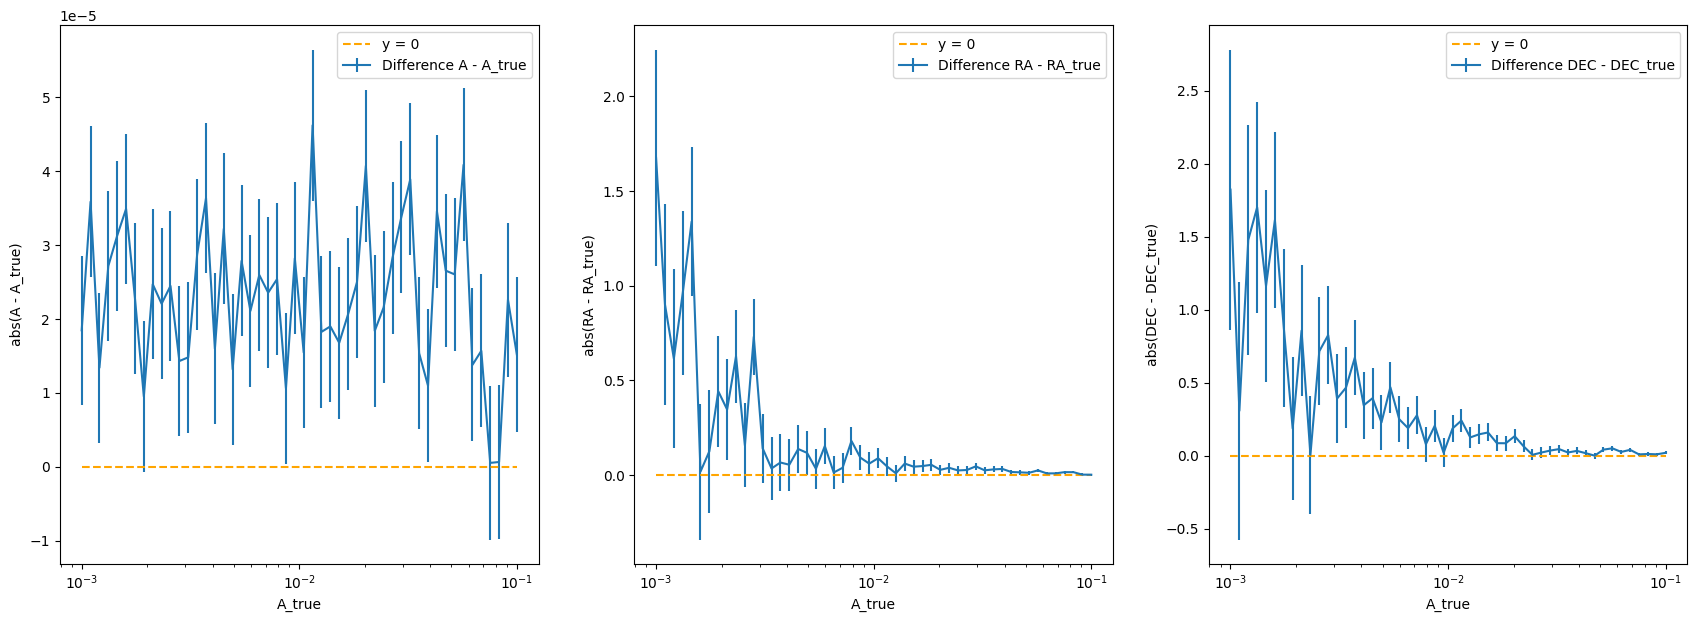

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(3*7,7))
compareFit_diff(dfMinuit_filtered, "A", "A", nsigma=2, figax=(fig, ax[0]), surface=False)
compareFit_diff(dfMinuit_filtered, "A", "ra", ylegend="RA", nsigma=2, figax=(fig, ax[1]), surface=False)
compareFit_diff(dfMinuit_filtered, "A", "dec", ylegend="DEC", nsigma=2, figax=(fig, ax[2]), surface=False)

clSuffix_NoClust = f"NoCluster_band_{band}"
poissSuffix = "_PoissVar"
output_path = "Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/"
output_path_NoClust = f"{output_path}Simul_Magnitude_ParamStudy_NoCluster/Simul_Magnitude_ParamStudy_{clSuffix_NoClust}/"

suffix = f"m5_A_study_diffARaDec_{clSuffix_NoClust}"
get_savefig(plt, output_path_NoClust, suffix + poissSuffix)

Saving m5_A_study_ratioARaDec_NoCluster_band_u_PoissVar in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_NoCluster/Simul_Magnitude_ParamStudy_NoCluster_band_u/m5_A_study_ratioARaDec_NoCluster_band_u_PoissVar.pdf


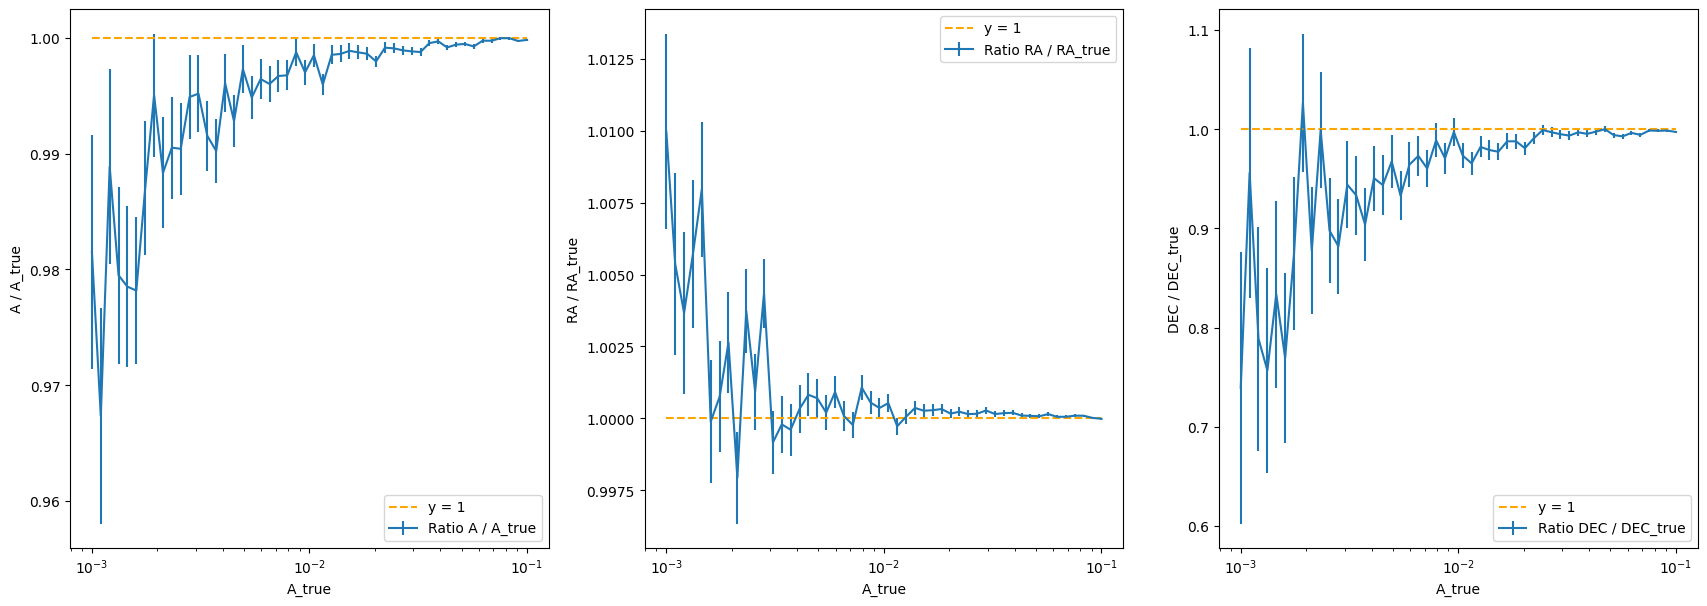

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(3*7,7))
compareFit_ratio(dfMinuit_filtered, "A", "A", nsigma=2, figax=(fig, ax[0]), surface=False)
compareFit_ratio(dfMinuit_filtered, "A", "ra", ylegend="RA", nsigma=2, figax=(fig, ax[1]), surface=False)
compareFit_ratio(dfMinuit_filtered, "A", "dec", ylegend="DEC", nsigma=2, figax=(fig, ax[2]), surface=False)
ax[0].legend(loc="lower right")
ax[2].legend(loc="lower right")

suffix = f"m5_A_study_ratioARaDec_{clSuffix_NoClust}"
get_savefig(plt, output_path_NoClust, suffix + poissSuffix)

Saving m5_A_study_ARaDec_NoCluster_band_u_PoissVar in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_NoCluster/Simul_Magnitude_ParamStudy_NoCluster_band_u/m5_A_study_ARaDec_NoCluster_band_u_PoissVar.pdf


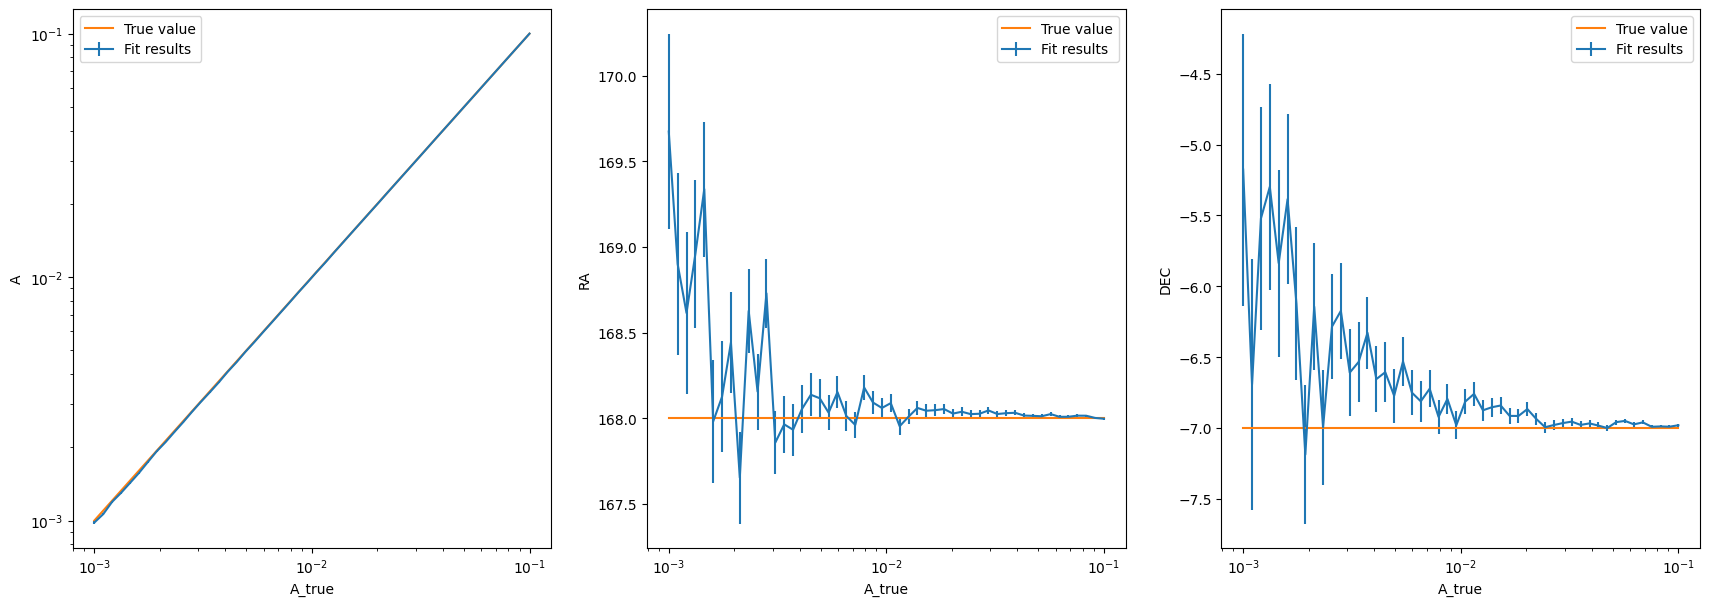

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(3*7,7))
compareFit_val(dfMinuit_filtered, "A", "A", nsigma=2, figax=(fig, ax[0]), surface=False, yscale='log')
compareFit_val(dfMinuit_filtered, "A", "ra", ylabel="RA", nsigma=2, figax=(fig, ax[1]), surface=False)
compareFit_val(dfMinuit_filtered, "A", "dec", ylabel="DEC", nsigma=2, figax=(fig, ax[2]), surface=False)
# ax[0].legend(loc="lower right")
# ax[2].legend(loc="lower right")

suffix = f"m5_A_study_ARaDec_{clSuffix_NoClust}"
get_savefig(plt, output_path_NoClust, suffix + poissSuffix)

Saving m5_A_study_A_DiffRatioNoCluster_band_u_PoissVar in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_NoCluster/Simul_Magnitude_ParamStudy_NoCluster_band_u/m5_A_study_A_DiffRatioNoCluster_band_u_PoissVar.pdf


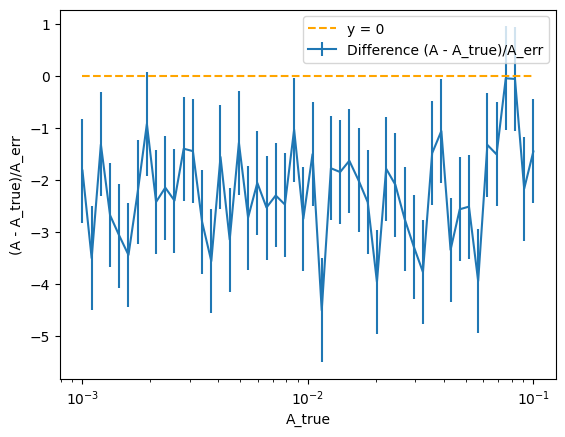

In [10]:
compareFit_diffRatio(dfMinuit_filtered, "A", "A", nsigma=1, surface=False)

suffix = f"m5_A_study_A_DiffRatio{clSuffix_NoClust}"
get_savefig(plt, output_path_NoClust, suffix + poissSuffix)

Saving m5_A_study_Acorr_DiffRatioNoCluster_band_u_PoissVar in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_NoCluster/Simul_Magnitude_ParamStudy_NoCluster_band_u/m5_A_study_Acorr_DiffRatioNoCluster_band_u_PoissVar.pdf


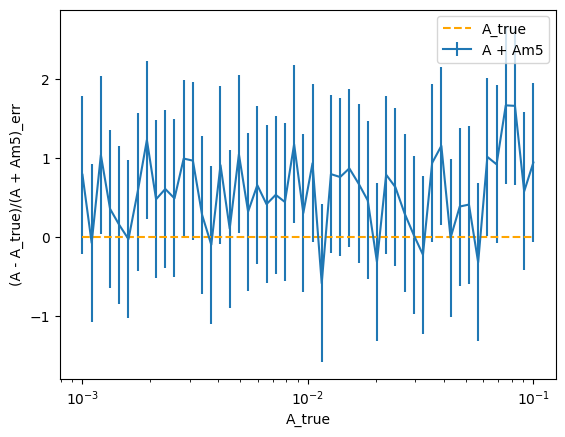

In [11]:
compareFit_diffRatio(dfMinuit_filtered, "A", "A+Am5", ytrue = "A_true", nsigma=1, surface=False, label_true="A_true", label_fit="A + Am5", ylabel="(A - A_true)/(A + Am5)_err")

suffix = f"m5_A_study_Acorr_DiffRatio{clSuffix_NoClust}"
get_savefig(plt, output_path_NoClust, suffix + poissSuffix)

## Study with clustering

count    10000.000000
mean         0.000704
std          0.000298
min          0.000033
25%          0.000485
50%          0.000681
75%          0.000896
max          0.002026
Name: A, dtype: float64

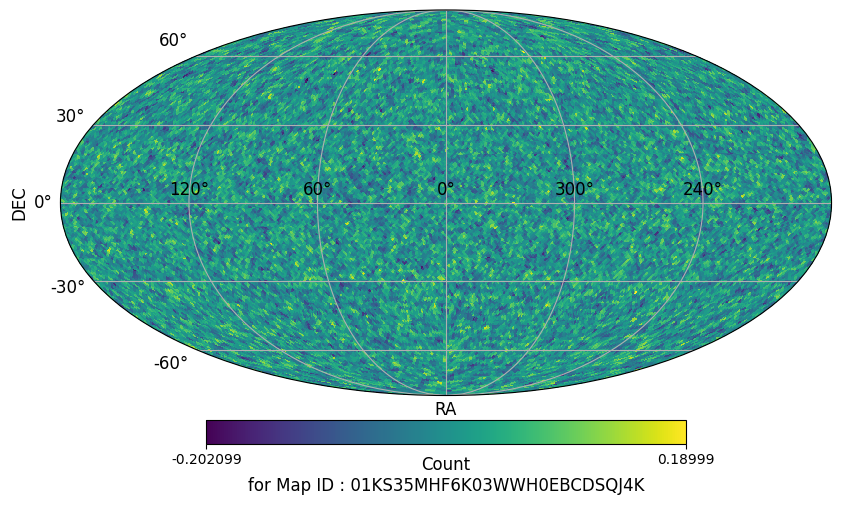

In [12]:
DIR = "Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_"
sufix = "zmin0.1"
clFile = DIR + sufix + '.fits'

with fitsio.FITS(clFile, 'rw') as fits:
    dfNumpy = Table(fits['FIT_NUMPY'].read()).to_pandas()
    clMapper = CountMapper.from_map_fits(fits, idx=0, nest=False) #first clustering map
    clMapper = clMapper.invert_nest()
clMapper.plot()

clStats = dfNumpy.describe()
clStats['A']

In [13]:
DIR = "Fit_m5/m5_Dipole/m5_Dipole_"
suffix = "Param_study_Cluster_poissVar"
outputfile = DIR + suffix +".fits"

data3 = fitsio.FITS(outputfile)
data3


  file: Fit_m5/m5_Dipole/m5_Dipole_Param_study_Cluster_poissVar.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      A_STUDY_MAPS_z
  2      BINARY_TBL      A_STUDY
  3      BINARY_TBL      A_STUDY_MAPS_i
  4      BINARY_TBL      A_STUDY_MAPS_u

In [14]:
dfMinuit_data3 = Table(data3['A_STUDY'].read())
dfMinuit_data3['A+Am5'] = dfMinuit_data3['A'] + m5Stats['A']['mean']
dfMinuit_data3['A+Am5_err'] = np.sqrt(dfMinuit_data3['A_err']**2 + m5Stats['A']['std']**2)
dfMinuit_data3['A-Am5'] = dfMinuit_data3['A'] - m5Stats['A']['mean']
dfMinuit_data3['A-Am5_err'] = np.sqrt(dfMinuit_data3['A_err']**2 + m5Stats['A']['std']**2)
dfMinuit_data3['A-Acl'] = dfMinuit_data3['A'] - clStats['A']['mean']
dfMinuit_data3['A-Acl_err'] = np.sqrt(dfMinuit_data3['A_err']**2 + clStats['A']['std']**2)
dfMinuit_data3['A+Am5-Acl'] = dfMinuit_data3['A+Am5'] - clStats['A']['mean']
dfMinuit_data3['A+Am5-Acl_err'] = np.sqrt(dfMinuit_data3['A+Am5_err']**2 + clStats['A']['std']**2)
dfMinuit_data3['A-Am5-Acl'] = dfMinuit_data3['A-Am5'] - clStats['A']['mean']
dfMinuit_data3['A-Am5-Acl_err'] = np.sqrt(dfMinuit_data3['A-Am5_err']**2 + clStats['A']['std']**2)
mask = dfMinuit_data3["BAND"] == band
dfMinuit_filtered = dfMinuit_data3[mask]
dfMinuit_filtered

Map_ID,N*,N*_init,N*_err,N*_fixed,N*_limit_0,N*_limit_1,A,A_init,A_err,A_fixed,A_limit_0,A_limit_1,ra,ra_init,ra_err,ra_fixed,ra_limit_0,ra_limit_1,dec,dec_init,dec_err,dec_fixed,dec_limit_0,dec_limit_1,valid,Nth_ID,Ratio_ID,BAND,N*_true,A_true,ra_true,dec_true,Cluster_ID,A+Am5,A+Am5_err,A-Am5,A-Am5_err,A-Acl,A-Acl_err,A+Am5-Acl,A+Am5-Acl_err,A-Am5-Acl,A-Am5-Acl_err
str26,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,bool,str26,str26,str1,int64,float64,int64,int64,str26,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
01KT6HQK3YSZH63K8Z55YH1XW5,997973.4541638881,1000000.0,8.831159764900804,False,0.0,inf,0.0017956916527348665,1.0,1.037979103760871e-05,False,0.0,1.0,190.33834723110868,100.0,0.3374723978954677,False,0.0,360.0,23.522706350905487,0.0,0.5207752648741568,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.001,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K,0.0018299791669297023,2.0312632413834457e-05,0.0017614041385400306,2.0312632413834457e-05,0.001091348940173612,0.00029772477670723057,0.001125636454368448,0.00029823632514998144,0.0010570614259787763,0.00029823632514998144
01KT6HQST6FTC348Y4EMSZG7ZW,997988.1402489522,1000000.0,8.832035727333277,False,0.0,inf,0.0019074714186215805,1.0,1.0250293802280199e-05,False,0.0,1.0,189.71804917076335,100.0,0.3137954858427321,False,0.0,360.0,21.806790326254827,0.0,0.49275272750345245,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.0010985411419875584,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K,0.0019417589328164164,2.024676509045828e-05,0.0018731839044267447,2.024676509045828e-05,0.001203128706060326,0.0002977202900818467,0.001237416220255162,0.00029823184622037615,0.0011688411918654904,0.00029823184622037615
01KT6HQXTCCP3F1YY33ZHYCCWJ,997981.9928839306,1000000.0,8.760396828176454,False,0.0,inf,0.001986289050520671,1.0,1.015308022691533e-05,False,0.0,1.0,188.19642204209023,100.0,0.2995928239578376,False,0.0,360.0,20.925284103382378,0.0,0.4702288158590555,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.0012067926406393288,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K,0.0020205765647155066,2.0197722933274317e-05,0.0019520015363258352,2.0197722933274317e-05,0.0012819463379594165,0.0002977169589416768,0.001316233852154252,0.00029822852079416413,0.0012476588237645809,0.00029822852079416413
01KT6HR3VYNTQ5S9BNXBDQR45T,997975.6916145443,1000000.0,8.832253741333261,False,0.0,inf,0.002084116980726885,1.0,1.00912215614795e-05,False,0.0,1.0,186.91058901853418,100.0,0.2828395560874526,False,0.0,360.0,19.376210488276843,0.0,0.45360801544222085,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.0013257113655901094,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K,0.0021184044949217207,2.0166698445655525e-05,0.0020498294665320495,2.0166698445655525e-05,0.0013797742681656306,0.00029771485578652056,0.0014140617823604662,0.00029822642124664923,0.001345486753970795,0.00029822642124664923
01KT6HR86AXZRFJ1K05XH2E6XZ,997996.092173539,1000000.0,8.832551294472069,False,0.0,inf,0.0021956230583946757,1.0,1.0038925109021697e-05,False,0.0,1.0,185.42823908226023,100.0,0.2671141379334898,False,0.0,360.0,18.46519897526779,0.0,0.4313572111146442,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.0014563484775012444,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K,0.0022299105725895113,2.0140580700160623e-05,0.00216133554419984,2.0140580700160623e-05,0.0014912803458334211,0.00029771308775519164,0.0015255678600282568,0.0002982246562481472,0.0014569928316385855,0.0002982246562481472
01KT6HRCXDMMSN877GP0JXDQET,997988.8842282898,1000000.0,8.83289866161067,False,0.0,inf,0.0023085046409451427,1.0,9.95397407202274e-06,False,0.0,1.0,184.47192822971587,100.0,0.25186282725152864,False,0.0,360.0,16.856665003208867,0.0,0.4115333012477489,Fa

Saving m5_A_study_Acorr_Cluster_band_u_PoissVar in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_Cluster/Simul_Magnitude_ParamStudy_Cluster_band_u/m5_A_study_Acorr_Cluster_band_u_PoissVar.pdf


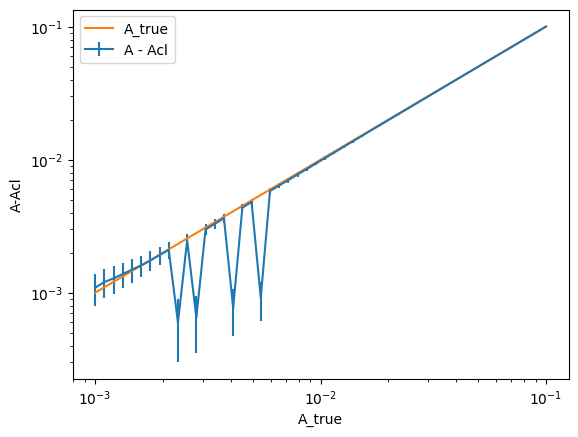

In [15]:
compareFit_val(dfMinuit_filtered, "A", "A-Acl", ytrue = "A_true", nsigma=1, surface=False, yscale='log', label_true="A_true", label_fit="A - Acl")

clSuffix_Clust = f"Cluster_band_{band}"
output_path = "Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/"
output_path_Clust = f"{output_path}Simul_Magnitude_ParamStudy_Cluster/Simul_Magnitude_ParamStudy_{clSuffix_Clust}/"
suffix = f"m5_A_study_Acorr_{clSuffix_Clust}"
get_savefig(plt, output_path_Clust, suffix + poissSuffix)

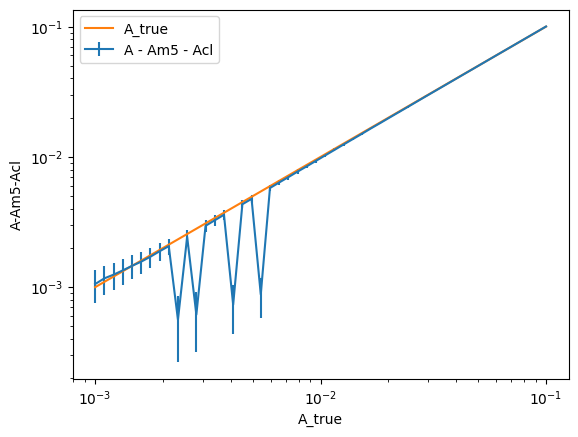

In [16]:
compareFit_val(dfMinuit_filtered, "A", "A-Am5-Acl", ytrue = "A_true", nsigma=1, surface=False, yscale='log', label_true="A_true", label_fit="A - Am5 - Acl")

Saving m5_A_study_Acorr_DiffRatioCluster_band_u_PoissVar in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_Cluster/Simul_Magnitude_ParamStudy_Cluster_band_u/m5_A_study_Acorr_DiffRatioCluster_band_u_PoissVar.pdf


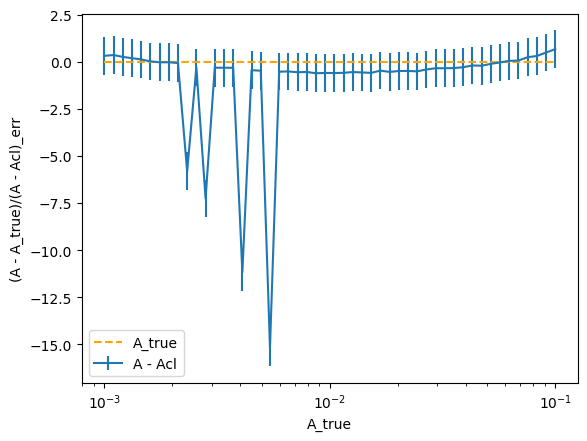

In [17]:
compareFit_diffRatio(dfMinuit_filtered, "A", "A-Acl", ytrue = "A_true", nsigma=1, surface=False, label_true="A_true", label_fit="A - Acl", ylabel="(A - A_true)/(A - Acl)_err")

suffix = f"m5_A_study_Acorr_DiffRatio{clSuffix_Clust}"
get_savefig(plt, output_path_Clust, suffix + poissSuffix)

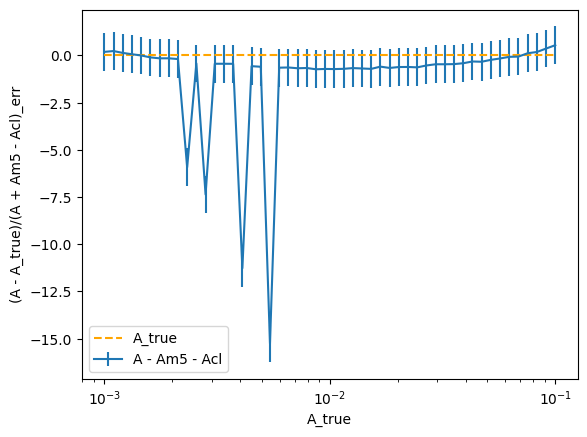

In [18]:
compareFit_diffRatio(dfMinuit_filtered, "A", "A-Am5-Acl", ytrue = "A_true", nsigma=1, surface=False, label_true="A_true", label_fit="A - Am5 - Acl", ylabel="(A - A_true)/(A + Am5 - Acl)_err")

Saving m5_A_study_Acorr_CompareCluster_band_u_PoissVar in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_Cluster/Simul_Magnitude_ParamStudy_Cluster_band_u/m5_A_study_Acorr_CompareCluster_band_u_PoissVar.pdf


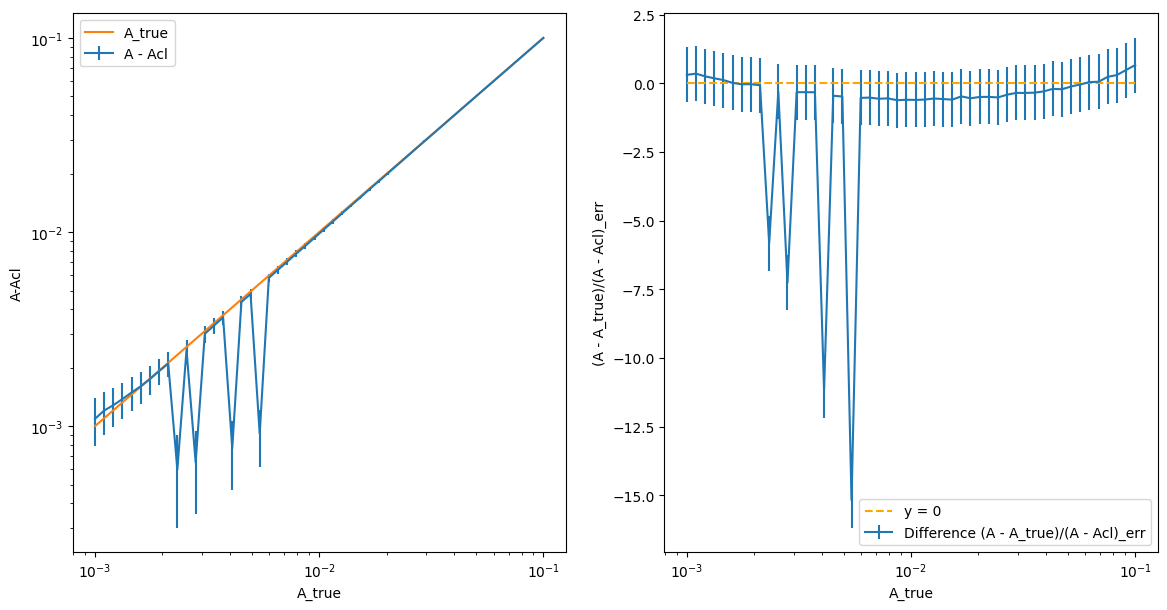

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(2*7,7))
compareFit_val(dfMinuit_filtered, "A", "A-Acl", ytrue = "A_true", nsigma=1, surface=False, yscale='log', label_true="A_true", label_fit="A - Acl", figax=(fig, ax[0]))
compareFit_diffRatio(dfMinuit_filtered, "A", "A-Acl", ytrue = "A_true", nsigma=1, surface=False, ylabel="(A - A_true)/(A - Acl)_err", figax=(fig, ax[1]))
ax[1].legend(loc='lower right')

suffix = f"m5_A_study_Acorr_Compare{clSuffix_Clust}"
get_savefig(plt, output_path_Clust, suffix + poissSuffix)

Saving m5_A_study_diffARaDec_Cluster_band_u_PoissVar in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_Cluster/Simul_Magnitude_ParamStudy_Cluster_band_u/m5_A_study_diffARaDec_Cluster_band_u_PoissVar.pdf


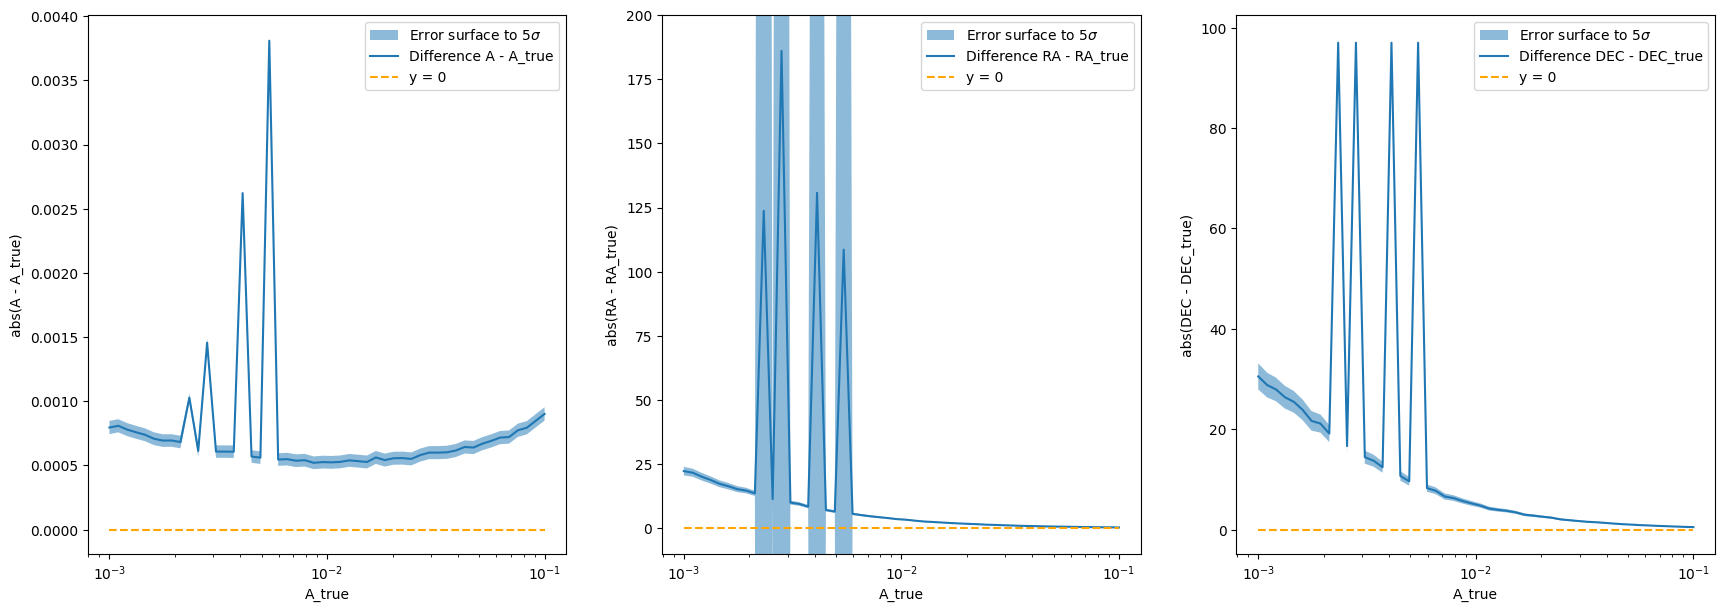

In [20]:
fig, ax = plt.subplots(1, 3, figsize=(3*7,7))
compareFit_diff(dfMinuit_filtered, "A", "A", nsigma=5, figax=(fig, ax[0]))
compareFit_diff(dfMinuit_filtered, "A", "ra", ylegend="RA", nsigma=5, figax=(fig, ax[1]))
compareFit_diff(dfMinuit_filtered, "A", "dec", ylegend="DEC", nsigma=5, figax=(fig, ax[2]))
ax[1].set_ylim([-10, 200])  #used for band u
#ax[1].set_ylim([-10, 130]) #used for band i

clSuffix_Clust = f"Cluster_band_{band}"
output_path = "Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/"
output_path_Clust = f"{output_path}Simul_Magnitude_ParamStudy_Cluster/Simul_Magnitude_ParamStudy_{clSuffix_Clust}/"
suffix = f"m5_A_study_diffARaDec_{clSuffix_Clust}"
get_savefig(plt, output_path_Clust, suffix + poissSuffix)

Saving m5_A_study_ratioARaDec_Cluster_band_u_PoissVar in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_Cluster/Simul_Magnitude_ParamStudy_Cluster_band_u/m5_A_study_ratioARaDec_Cluster_band_u_PoissVar.pdf


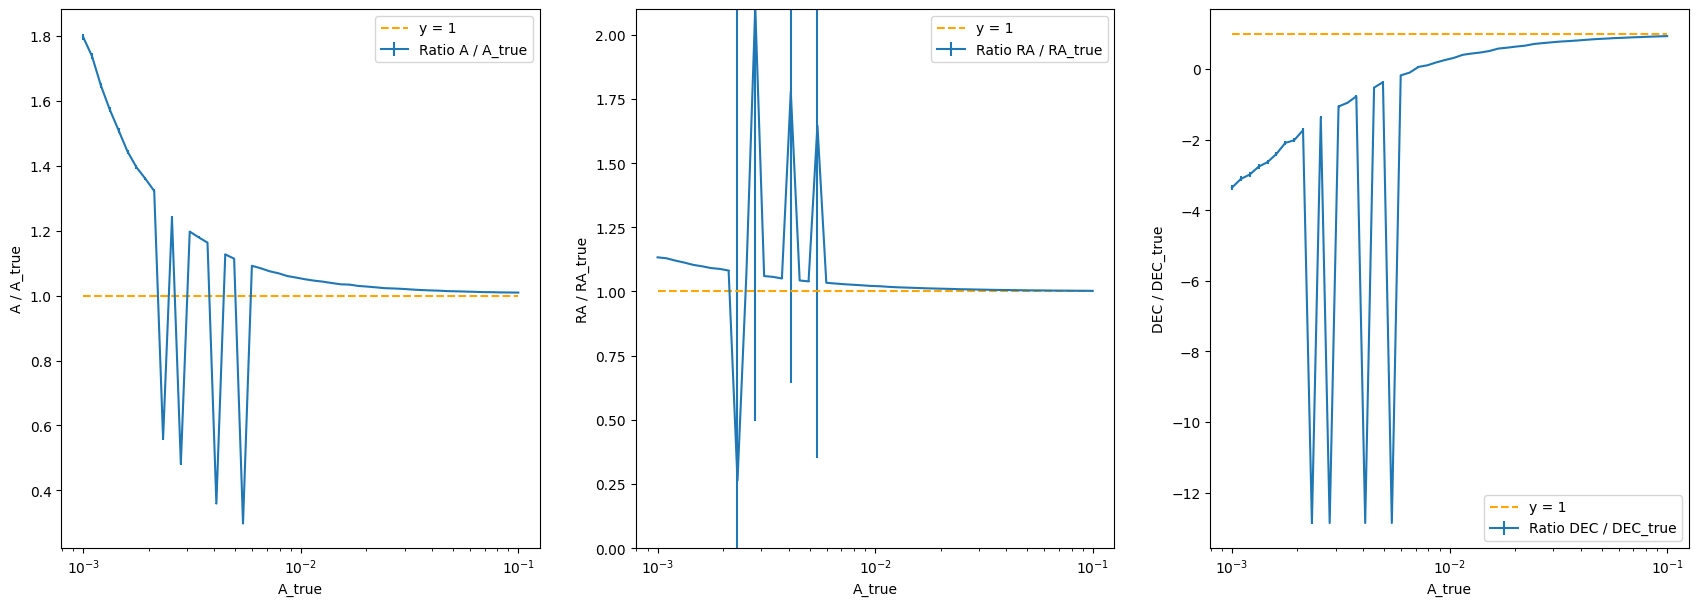

In [21]:
fig, ax = plt.subplots(1, 3, figsize=(3*7,7))
compareFit_ratio(dfMinuit_filtered, "A", "A", nsigma=2, figax=(fig, ax[0]), surface=False)
compareFit_ratio(dfMinuit_filtered, "A", "ra", ylegend="RA", nsigma=2, figax=(fig, ax[1]), surface=False)
compareFit_ratio(dfMinuit_filtered, "A", "dec", ylegend="DEC", nsigma=2, figax=(fig, ax[2]), surface=False)
#ax[0].legend(loc="lower right")
ax[2].legend(loc="lower right")
#ax[1].set_ylim([0.3, 2]) #used for band i
ax[1].set_ylim([0, 2.1]) #used for band u

suffix = f"m5_A_study_ratioARaDec_{clSuffix_Clust}"
get_savefig(plt, output_path_Clust, suffix + poissSuffix)

Saving CorrectMap_m5band_u_DipCluster_PoissVar in Simul_Figures/Simul_Magnitude/CorrectMap_m5band_u_DipCluster_PoissVar.pdf


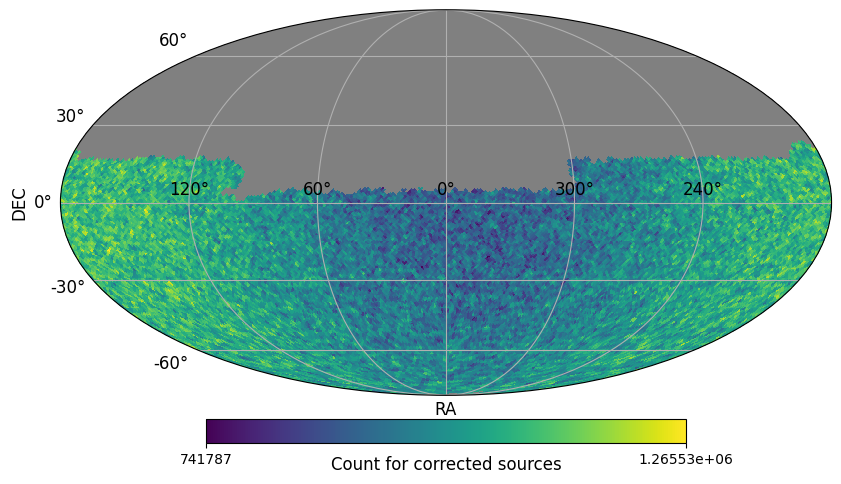

In [22]:
correctMapper = CountMapper.from_map_fits(data3, 49, HDU=f"A_STUDY_MAPS_{band}", IDinunit=False)
correctMapper._set_suffixTextPlot(unit = "corrected sources")
correctMapper.set_mask()
correctMapper.plot("Masked")

output_path = "Simul_Figures/Simul_Magnitude/"
suffix = f"CorrectMap_m5band_{band}_DipCluster"
get_savefig(plt, output_path, suffix + poissSuffix)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 6.671e+07 (χ²/ndof = 1357.3)│              Nfcn = 308              │
│ EDM = 6.69e-07 (Goal: 0.0002)    │            time = 3.6 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │ 997.966e3 │  0.009e3  │  -0.009e3  │  0.009e3   │    0    │         │       │
│ 1 │ A    │100.901e-3 │ 0.010e-3  │ -0.010e-3  │  0.010e-3  │    0    │    1    │       │
│ 2 │ ra   │  168.396  │   0.006   │   -0.006   │   0.006    │    0    │   360   │       │
│ 3 │ dec  │  -6.502   │   0.009   │   -0.009   │   0.009    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │    -9     │     9     │ -0.01e-3  │  0.01e-3  │  -0.006   │   0.006   │  -0.009   │   0.009   │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────┐
│     │           N*            A           ra          dec │
├─────┼─────────────────────────────────────────────────────┤
│  N* │         78.1 -29.08760e-6    -4.958e-3     61.87e-3 │
│   A │ -29.08760e-6     1.08e-10      2.57e-9    -28.32e-9 │
│  ra │    -4.958e-3      2.57e-9     3.13e-05    -0.005e-3 │
│ dec │     61.87e-3    -28.32e-9    -0.005e-3     8.78e-05 │
└─────┴─────────────────────────────────────────────────────┘

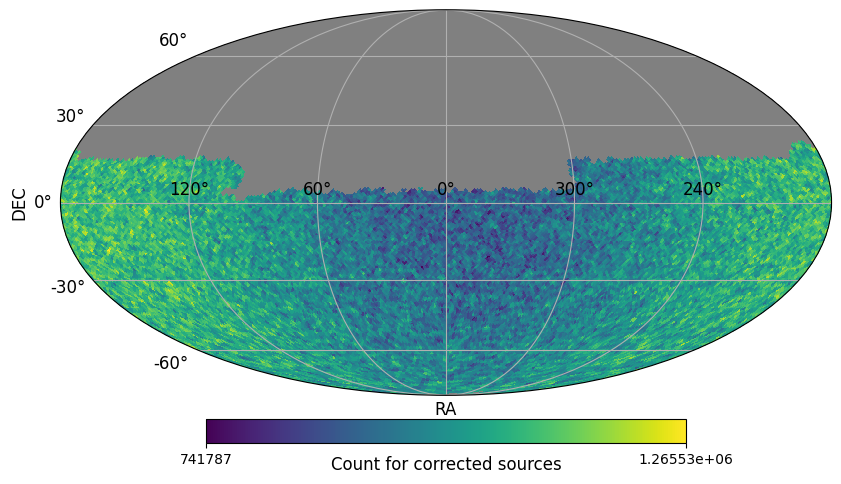

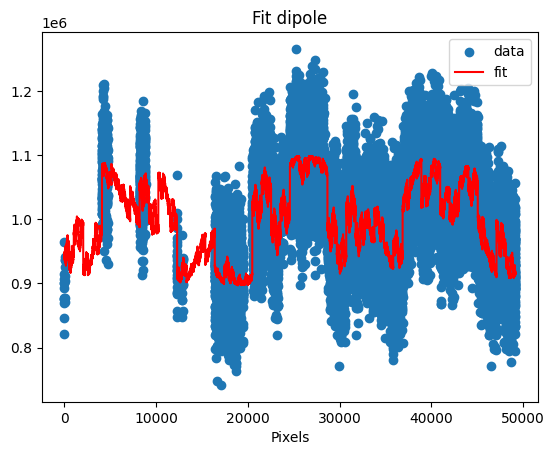

In [23]:
correctMapper.fit_dipole("Masked", init=(NSource_px_th, 1, 100, 0))

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 5.864e+04 (χ²/ndof = 1.2)  │              Nfcn = 311              │
│ EDM = 5.34e-07 (Goal: 0.0002)    │            time = 3.5 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │1.000002e6 │0.000009e6 │-0.000009e6 │ 0.000009e6 │    0    │         │       │
│ 1 │ A    │ 99.985e-3 │ 0.010e-3  │ -0.010e-3  │  0.010e-3  │    0    │    1    │       │
│ 2 │ ra   │  167.998  │   0.006   │   -0.006   │   0.006    │    0    │   360   │       │
│ 3 │ dec  │  -6.980   │   0.009   │   -0.009   │   0.009    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │    -9     │     9     │ -0.01e-3  │  0.01e-3  │  -0.006   │   0.006   │  -0.009   │   0.009   │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────┐
│     │           N*            A           ra          dec │
├─────┼─────────────────────────────────────────────────────┤
│  N* │         78.2 -29.91432e-6    -5.087e-3     62.31e-3 │
│   A │ -29.91432e-6     1.09e-10      2.73e-9    -29.22e-9 │
│  ra │    -5.087e-3      2.73e-9     3.19e-05    -0.005e-3 │
│ dec │     62.31e-3    -29.22e-9    -0.005e-3      8.9e-05 │
└─────┴─────────────────────────────────────────────────────┘

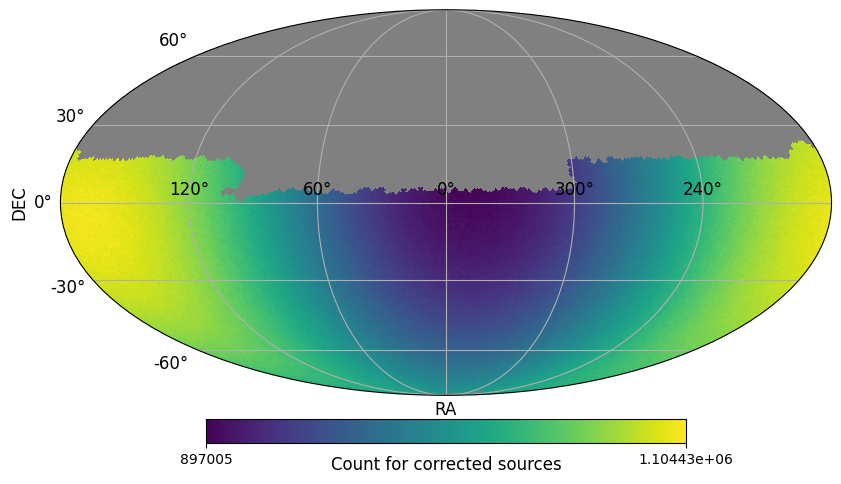

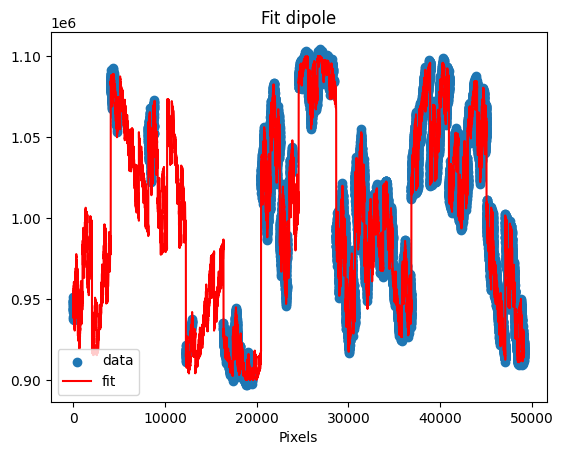

In [24]:
correctMapper = CountMapper.from_map_fits(data2, 49, HDU=f"A_STUDY_MAPS_{band}", IDinunit=False)
correctMapper._set_suffixTextPlot(unit = "corrected sources")
correctMapper.set_mask()
correctMapper.fit_dipole("Masked", init=(NSource_px_th, 1, 100, 0))